<a href="https://colab.research.google.com/github/jomartinezdi-UNAL/Proyecto-PMN/blob/main/PMN_EDA_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA - Base de datos de accidentes aéreos Aerocivil
Propósito: Identificar tipos de datos, nulos, atípicos y sugerir codificacionesIA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Configurar visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("="*80)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("Base de datos de accidentes aéreos - Aerocivil")
print("="*80)

ANÁLISIS EXPLORATORIO DE DATOS (EDA)
Base de datos de accidentes aéreos - Aerocivil


In [6]:
# ============================================================================
# 1. CARGA DE DATOS
# ============================================================================

try:
    df = pd.read_csv('accidentes_aereos.csv', encoding='latin1', low_memory=False)
    print("✓ Archivo cargado exitosamente")
except FileNotFoundError:
    print("! Archivo no encontrado. Creando estructura de ejemplo...")
    print("  Reemplaza esta sección con: df = pd.read_csv('tu_archivo.csv')")

    # Crear datos de ejemplo para demostración
    np.random.seed(42)
    n_muestras = 1000

    # Fechas aleatorias (últimos 15 años)
    fechas = pd.date_range('2010-01-01', '2024-12-31', periods=n_muestras)

    df = pd.DataFrame({
        'Fecha': fechas,
        'Departamento': np.random.choice(['Antioquia', 'Cundinamarca', 'Valle', 'Bolívar', 'Santander'], n_muestras),
        'Municipio': np.random.choice(['Medellín', 'Bogotá', 'Cali', 'Cartagena', 'Bucaramanga'], n_muestras),
        'Fase de vuelo': np.random.choice(['Despegue', 'Crucero', 'Aterrizaje', 'Taxeo', 'Maniobras'], n_muestras),
        'Misión del vuelo': np.random.choice(['Privado', 'Comercial', 'Entrenamiento', 'Aeronavegación'], n_muestras),
        'Total fatales': np.random.poisson(0.5, n_muestras),
        'Total graves': np.random.poisson(0.3, n_muestras),
        'Total leves': np.random.poisson(0.8, n_muestras),
        'Total ilesos': np.random.poisson(2, n_muestras),
        'Porcentaje de superviviencia': np.random.uniform(0, 100, n_muestras),
        'Causa probable': np.random.choice(['Pérdida de control', 'Falla de motor', 'Error humano',
                                              'Condiciones climáticas', 'Choque con ave'], n_muestras),
        'Fabricante': np.random.choice(['Cessna', 'Piper', 'Beechcraft', 'Airbus', 'Boeing'], n_muestras),
        'Año de fabricación': np.random.randint(1970, 2020, n_muestras),
        'No. Tripulantes': np.random.randint(1, 6, n_muestras),
        'No. Pasajeros': np.random.randint(0, 50, n_muestras),
    })

    # Agregar algunos nulos intencionales
    for col in ['Total fatales', 'Causa probable', 'Fabricante']:
        idx_nulos = np.random.choice(df.index, size=int(0.05*n_muestras), replace=False)
        df.loc[idx_nulos, col] = np.nan

    # Agregar algunos valores atípicos
    df.loc[np.random.choice(df.index, 5), 'Total fatales'] = np.random.randint(50, 100, 5)
    df.loc[np.random.choice(df.index, 3), 'Porcentaje de superviviencia'] = np.random.uniform(200, 500, 3)

print(f"✓ Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")

✓ Archivo cargado exitosamente
✓ Dimensiones: 112 filas, 177 columnas


In [7]:
# ============================================================================
# 2. INFORMACIÓN GENERAL DEL DATAFRAME
# ============================================================================
print("\n2. INFORMACIÓN GENERAL DEL DATAFRAME")
print("-"*50)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación de columnas:")
print(df.info())


2. INFORMACIÓN GENERAL DEL DATAFRAME
--------------------------------------------------

Primeras 5 filas:
  Código investigación       Clasificación Matrícula     Fecha Fecha UTC  \
0      COL-23-22-DIACC        1. Accidente    HK1635  20-04-23  20-04-23   
1      COL-23-18-DIACC  2. Incidente grave    CC-COY  15-03-23  15-03-23   
2      COL-23-12-DIACC  2. Incidente grave    HK5025  25-02-23  25-02-23   
3      COL-22-79-DIACC        1. Accidente    HK5121  21-11-22  21-11-22   
4      COL-22-77-DIACC  2. Incidente grave    HK3072  01-11-22  01-11-22   

    Hora Hora UTC Condiciones de luz    Estado Sigla estado Departamento  \
0  17:20    22:20                Día  Colombia          COL     Casanare   
1  15:49    20:49                Día  Colombia          COL  Bogotá D.C.   
2  11:49    16:49                Día  Colombia          COL       Boyacá   
3  10:15    15:15                Día  Colombia          COL    Antioquia   
4  16:00    21:00                Día  Colombia         

In [8]:
# ============================================================================
# 3. ANÁLISIS DE TIPOS DE DATOS
# ============================================================================
print("\n3. ANÁLISIS DE TIPOS DE DATOS")
print("-"*50)

tipos_datos = pd.DataFrame({
    'Tipo_dato': df.dtypes,
    'Es_numérico': df.dtypes.apply(lambda x: pd.api.types.is_numeric_dtype(x)),
    'Es_categórico': df.dtypes.apply(lambda x: pd.api.types.is_object_dtype(x) or pd.api.types.is_categorical_dtype(x)),
    'Es_fecha': df.dtypes.apply(lambda x: pd.api.types.is_datetime64_any_dtype(x)),
    'N_unique': df.nunique()
})

print("\nResumen por tipo de dato:")
print(tipos_datos.groupby('Tipo_dato').size())
print("\nDetalle por columna (primeras 20):")
print(tipos_datos.head(20))

# Identificar columnas numéricas y categóricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
columnas_fecha = df.select_dtypes(include=['datetime64']).columns.tolist()

print(f"\n✓ Columnas numéricas ({len(columnas_numericas)}): {columnas_numericas[:10]}...")
print(f"✓ Columnas categóricas ({len(columnas_categoricas)}): {columnas_categoricas[:10]}...")
print(f"✓ Columnas fecha ({len(columnas_fecha)}): {columnas_fecha}")


3. ANÁLISIS DE TIPOS DE DATOS
--------------------------------------------------

Resumen por tipo de dato:
Tipo_dato
int64       23
float64     38
object     116
dtype: int64

Detalle por columna (primeras 20):
                          Tipo_dato  Es_numérico  Es_categórico  Es_fecha  \
Código investigación         object        False           True     False   
Clasificación                object        False           True     False   
Matrícula                    object        False           True     False   
Fecha                        object        False           True     False   
Fecha UTC                    object        False           True     False   
Hora                         object        False           True     False   
Hora UTC                     object        False           True     False   
Condiciones de luz           object        False           True     False   
Estado                       object        False           True     False   
Sigla estado     


4. ANÁLISIS DE DATOS NULOS
--------------------------------------------------

Top 20 columnas con más nulos:
                             Nulos  Porcentaje
CONCATENADO                    112  100.000000
FACTORES INVOLUCRADOS          112  100.000000
Cantidad de recomendaciones    110   98.214286
Tipo de tren                   107   95.535714
Tipo de tren de aterrizaje     107   95.535714
ATS                            106   94.642857
Aeródromo.1                    106   94.642857
Detalle punto de aterrizaje    106   94.642857
Detalle del incendio           105   93.750000
Obstaculos                     105   93.750000
Detalle componente             105   93.750000
Tipo del terreno               103   91.964286
Detalle destino                103   91.964286
Alerta                         103   91.964286
Componente que falla           102   91.071429
Detalle origen                  99   88.392857
Mantenimiento                   98   87.500000
Detalle de la falla             97   86.607

<Figure size 4000x2000 with 0 Axes>

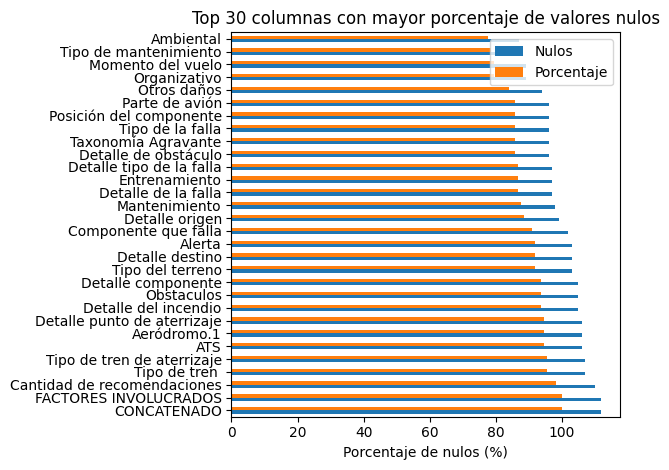

In [25]:
# ============================================================================
# 4. ANÁLISIS DE DATOS NULOS
# ============================================================================
print("\n4. ANÁLISIS DE DATOS NULOS")
print("-"*50)

nulos = df.isnull().sum()
nulos_porcentaje = (nulos / len(df)) * 100
nulos_df = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje': nulos_porcentaje
}).sort_values('Nulos', ascending=False)

print("\nTop 20 columnas con más nulos:")
print(nulos_df.head(20))

# Clasificar columnas según su nivel de nulos
columnas_buenas = nulos_df[nulos_df['Porcentaje'] < 5].index.tolist()
columnas_medias = nulos_df[(nulos_df['Porcentaje'] >= 5) & (nulos_df['Porcentaje'] < 30)].index.tolist()
columnas_malas = nulos_df[nulos_df['Porcentaje'] >= 30].index.tolist()

print(f"\n✓ Columnas con <5% nulos (buenas): {len(columnas_buenas)}")
print(f"✓ Columnas con 5-30% nulos (medias): {len(columnas_medias)}")
print(f"✓ Columnas con >30% nulos (malas): {len(columnas_malas)}")

# Visualización de nulos
plt.figure(figsize=(40, 20))
nulos_df.head(30).plot(kind='barh')
plt.title('Top 30 columnas con mayor porcentaje de valores nulos')
plt.xlabel('Porcentaje de nulos (%)')
plt.tight_layout()
plt.savefig('nulos_por_columna.png', dpi=300)
print("\n✓ Gráfico guardado: nulos_por_columna.png")

In [13]:
# ============================================================================
# 5. ESTADÍSTICAS PARA DATOS NUMÉRICOS
# ============================================================================
print("\n5. ESTADÍSTICAS DESCRIPTIVAS - DATOS NUMÉRICOS")
print("-"*50)

if len(columnas_numericas) > 0:
    estadisticas_numericas = df[columnas_numericas].describe()
    print("\nEstadísticas generales:")
    print(estadisticas_numericas)

    # Promedios específicos
    print("\n✓ Promedios por columna:")
    promedios = df[columnas_numericas].mean()
    for col in columnas_numericas[:10]:
        print(f"  - {col}: {promedios[col]:.2f}")

    # Guardar estadísticas completas
    estadisticas_numericas.to_csv('estadisticas_numericas.csv')
    print("\n✓ Estadísticas guardadas en: estadisticas_numericas.csv")
else:
    print("No hay columnas numéricas en el dataset")


5. ESTADÍSTICAS DESCRIPTIVAS - DATOS NUMÉRICOS
--------------------------------------------------

Estadísticas generales:
            Cod.D       Cod.M         LAG         LAM         LAS         LOG  \
count  112.000000  111.000000  112.000000  112.000000  112.000000  112.000000   
mean    51.383929   51.929505    4.714286   30.741071   31.536875   73.223214   
std     33.028856   33.108666    2.376418   16.219078   18.160023    2.208541   
min      5.000000    5.001000    0.000000    1.000000    0.000000   67.000000   
25%     14.500000   14.049000    4.000000   14.750000   16.322500   72.000000   
50%     50.000000   50.350000    4.000000   32.000000   35.225000   74.000000   
75%     85.000000   85.184500    6.000000   47.250000   46.425000   75.000000   
max     99.000000   99.524000   11.000000   58.000000   59.420000   77.000000   

              LOM         LOS     LAT GMS    LONG GMS   LAT ECCAIRS  \
count  112.000000  112.000000  112.000000  112.000000  1.060000e+02   
mean


6. DETECCIÓN DE VALORES ATÍPICOS
--------------------------------------------------

  LAG:
    - Outliers detectados: 12 (10.71%)
    - Rango normal: [1.00, 9.00]

  LOG:
    - Outliers detectados: 3 (2.68%)
    - Rango normal: [67.50, 79.50]

  LAT GMS:
    - Outliers detectados: 14 (12.50%)
    - Rango normal: [1.18, 9.19]

  LONG GMS:
    - Outliers detectados: 3 (2.68%)
    - Rango normal: [-79.02, -68.74]

✓ Boxplots guardados en: boxplots_outliers.png


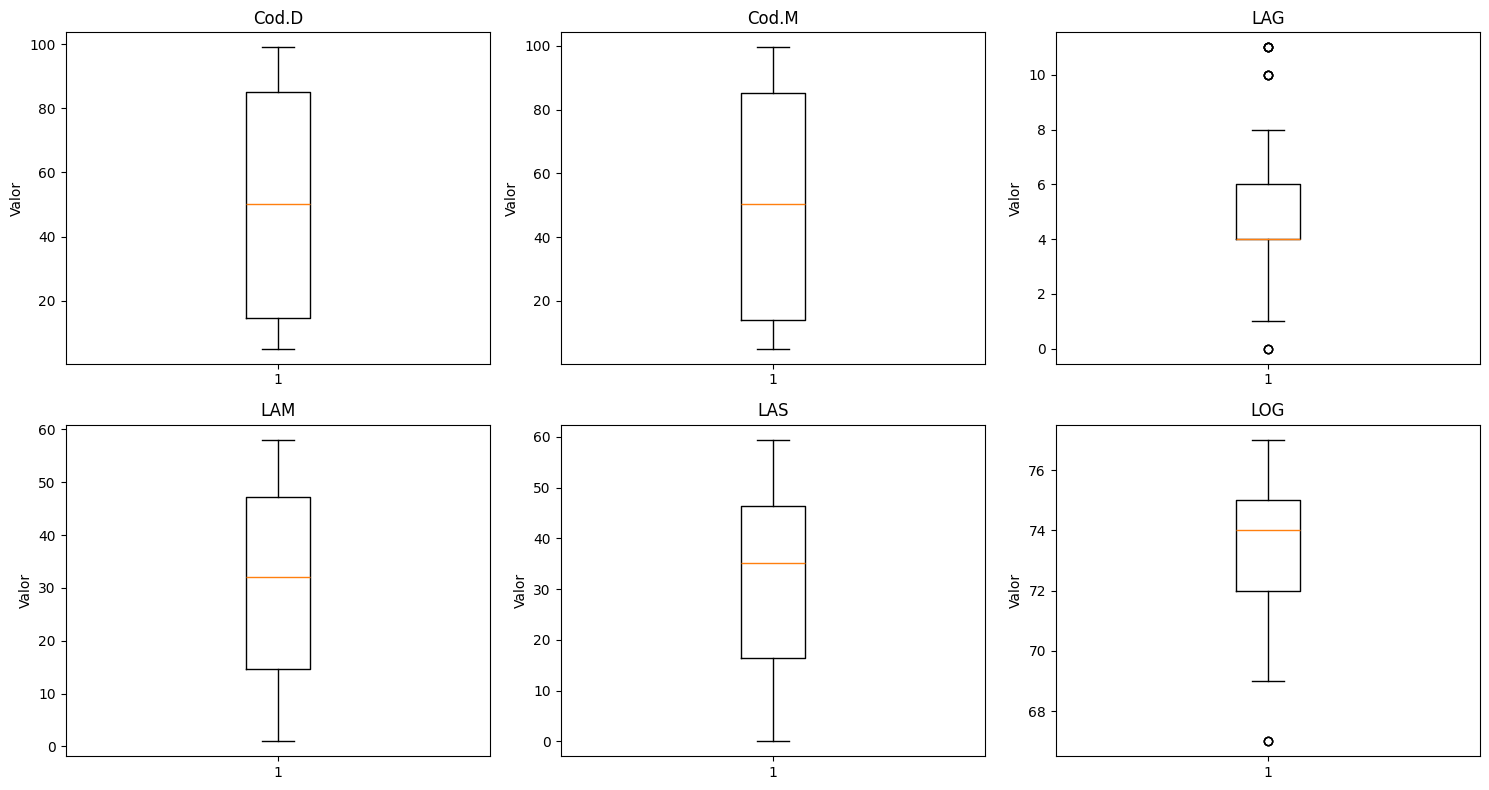

In [14]:
# ============================================================================
# 6. DETECCIÓN DE VALORES ATÍPICOS (OUTLIERS)
# ============================================================================
print("\n6. DETECCIÓN DE VALORES ATÍPICOS")
print("-"*50)

outliers_dict = {}
for col in columnas_numericas[:10]:  # Limitados a 10
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    n_outliers = len(outliers)
    porcentaje_outliers = (n_outliers / len(df)) * 100

    if n_outliers > 0:
        outliers_dict[col] = {
            'n_outliers': n_outliers,
            'porcentaje': porcentaje_outliers,
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior
        }
        print(f"\n  {col}:")
        print(f"    - Outliers detectados: {n_outliers} ({porcentaje_outliers:.2f}%)")
        print(f"    - Rango normal: [{limite_inferior:.2f}, {limite_superior:.2f}]")

# Visualización con boxplots
if len(columnas_numericas) > 0:
    n_cols = min(len(columnas_numericas), 6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(columnas_numericas[:6]):
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(col)
        axes[i].set_ylabel('Valor')
    plt.tight_layout()
    plt.savefig('boxplots_outliers.png', dpi=100)
    print("\n✓ Boxplots guardados en: boxplots_outliers.png")

In [15]:
# ============================================================================
# 7. ANÁLISIS DE DATOS CATEGÓRICOS Y PROPUESTA DE CODIFICACIÓN
# ============================================================================
print("\n7. ANÁLISIS DE DATOS CATEGÓRICOS Y CODIFICACIÓN")
print("-"*50)

propuesta_codificacion = []

for col in columnas_categoricas[:15]:  # Limitados a 15
    valores_unicos = df[col].dropna().unique()
    n_categorias = len(valores_unicos)
    frecuencias = df[col].value_counts()
    categoria_mas_frecuente = frecuencias.index[0] if len(frecuencias) > 0 else None
    frecuencia_mas_alta = frecuencias.iloc[0] if len(frecuencias) > 0 else 0

    # Proponer método de codificación según número de categorías
    if n_categorias <= 2:
        metodo = "Codificación binaria (0/1)"
        ejemplo = f"'{categoria_mas_frecuente}' → 1, otros → 0"
    elif n_categorias <= 10:
        metodo = "One-Hot Encoding (crear columnas binarias por categoría)"
        ejemplo = f"Se crearían {n_categorias} columnas"
    elif n_categorias <= 50:
        metodo = "Codificación ordinal (si hay orden natural) o frecuencia"
        ejemplo = f"Asignar orden según frecuencia: {list(frecuencias.head(3).index)}"
    else:
        metodo = "Codificación por frecuencia o target encoding (con precaución)"
        ejemplo = f"Demasiadas categorías ({n_categorias}) → agrupar las menos frecuentes en 'Otros'"

    propuesta_codificacion.append({
        'Columna': col,
        'N_categorías': n_categorias,
        'Categoría_más_frecuente': categoria_mas_frecuente,
        'Frecuencia': frecuencia_mas_alta,
        'Método_sugerido': metodo,
        'Ejemplo': ejemplo
    })

    print(f"\n  {col}:")
    print(f"    - Categorías únicas: {n_categorias}")
    print(f"    - Más común: '{categoria_mas_frecuente}' ({frecuencia_mas_alta} ocurrencias)")
    print(f"    - Método sugerido: {metodo}")
    print(f"    - Ejemplo: {ejemplo}")

# Guardar propuesta de codificación
df_codificacion = pd.DataFrame(propuesta_codificacion)
df_codificacion.to_csv('propuesta_codificacion_categorias.csv', index=False)
print("\n✓ Propuesta de codificación guardada en: propuesta_codificacion_categorias.csv")


7. ANÁLISIS DE DATOS CATEGÓRICOS Y CODIFICACIÓN
--------------------------------------------------

  Código investigación:
    - Categorías únicas: 112
    - Más común: 'COL-23-22-DIACC' (1 ocurrencias)
    - Método sugerido: Codificación por frecuencia o target encoding (con precaución)
    - Ejemplo: Demasiadas categorías (112) → agrupar las menos frecuentes en 'Otros'

  Clasificación:
    - Categorías únicas: 2
    - Más común: '1. Accidente' (63 ocurrencias)
    - Método sugerido: Codificación binaria (0/1)
    - Ejemplo: '1. Accidente' → 1, otros → 0

  Matrícula:
    - Categorías únicas: 105
    - Más común: 'HK1635' (2 ocurrencias)
    - Método sugerido: Codificación por frecuencia o target encoding (con precaución)
    - Ejemplo: Demasiadas categorías (105) → agrupar las menos frecuentes en 'Otros'

  Fecha:
    - Categorías únicas: 110
    - Más común: '12-04-15' (2 ocurrencias)
    - Método sugerido: Codificación por frecuencia o target encoding (con precaución)
    - Ejem


8. MATRIZ DE CORRELACIONES
--------------------------------------------------

Correlaciones fuertes encontradas (|r| > 0.5):
  Cod.D ↔ Cantidad de recomendaciones: -1.000
  Cod.M ↔ Cantidad de recomendaciones: -1.000
  LAG ↔ Cantidad de recomendaciones: -1.000
  LAS ↔ Cantidad de recomendaciones: -1.000
  LOG ↔ Cantidad de recomendaciones: 1.000
  LOM ↔ Cantidad de recomendaciones: 1.000
  LOS ↔ Cantidad de recomendaciones: -1.000
  LAT GMS ↔ Cantidad de recomendaciones: -1.000
  LAT ECCAIRS ↔ Cantidad de recomendaciones: -1.000
  LONG ECCAIRS ↔ Cantidad de recomendaciones: -1.000
  No. Tripulantes ↔ Cantidad de recomendaciones: 1.000
  No. Pasajeros ↔ Cantidad de recomendaciones: 1.000
  Total Abordo ↔ Cantidad de recomendaciones: 1.000
  Fatales tripulación ↔ Cantidad de recomendaciones: -1.000
  Ilesos tripulación ↔ Cantidad de recomendaciones: 1.000
  Ilesos pasajeros ↔ Cantidad de recomendaciones: 1.000
  Total fatales ↔ Cantidad de recomendaciones: -1.000
  Total ilesos ↔ Canti

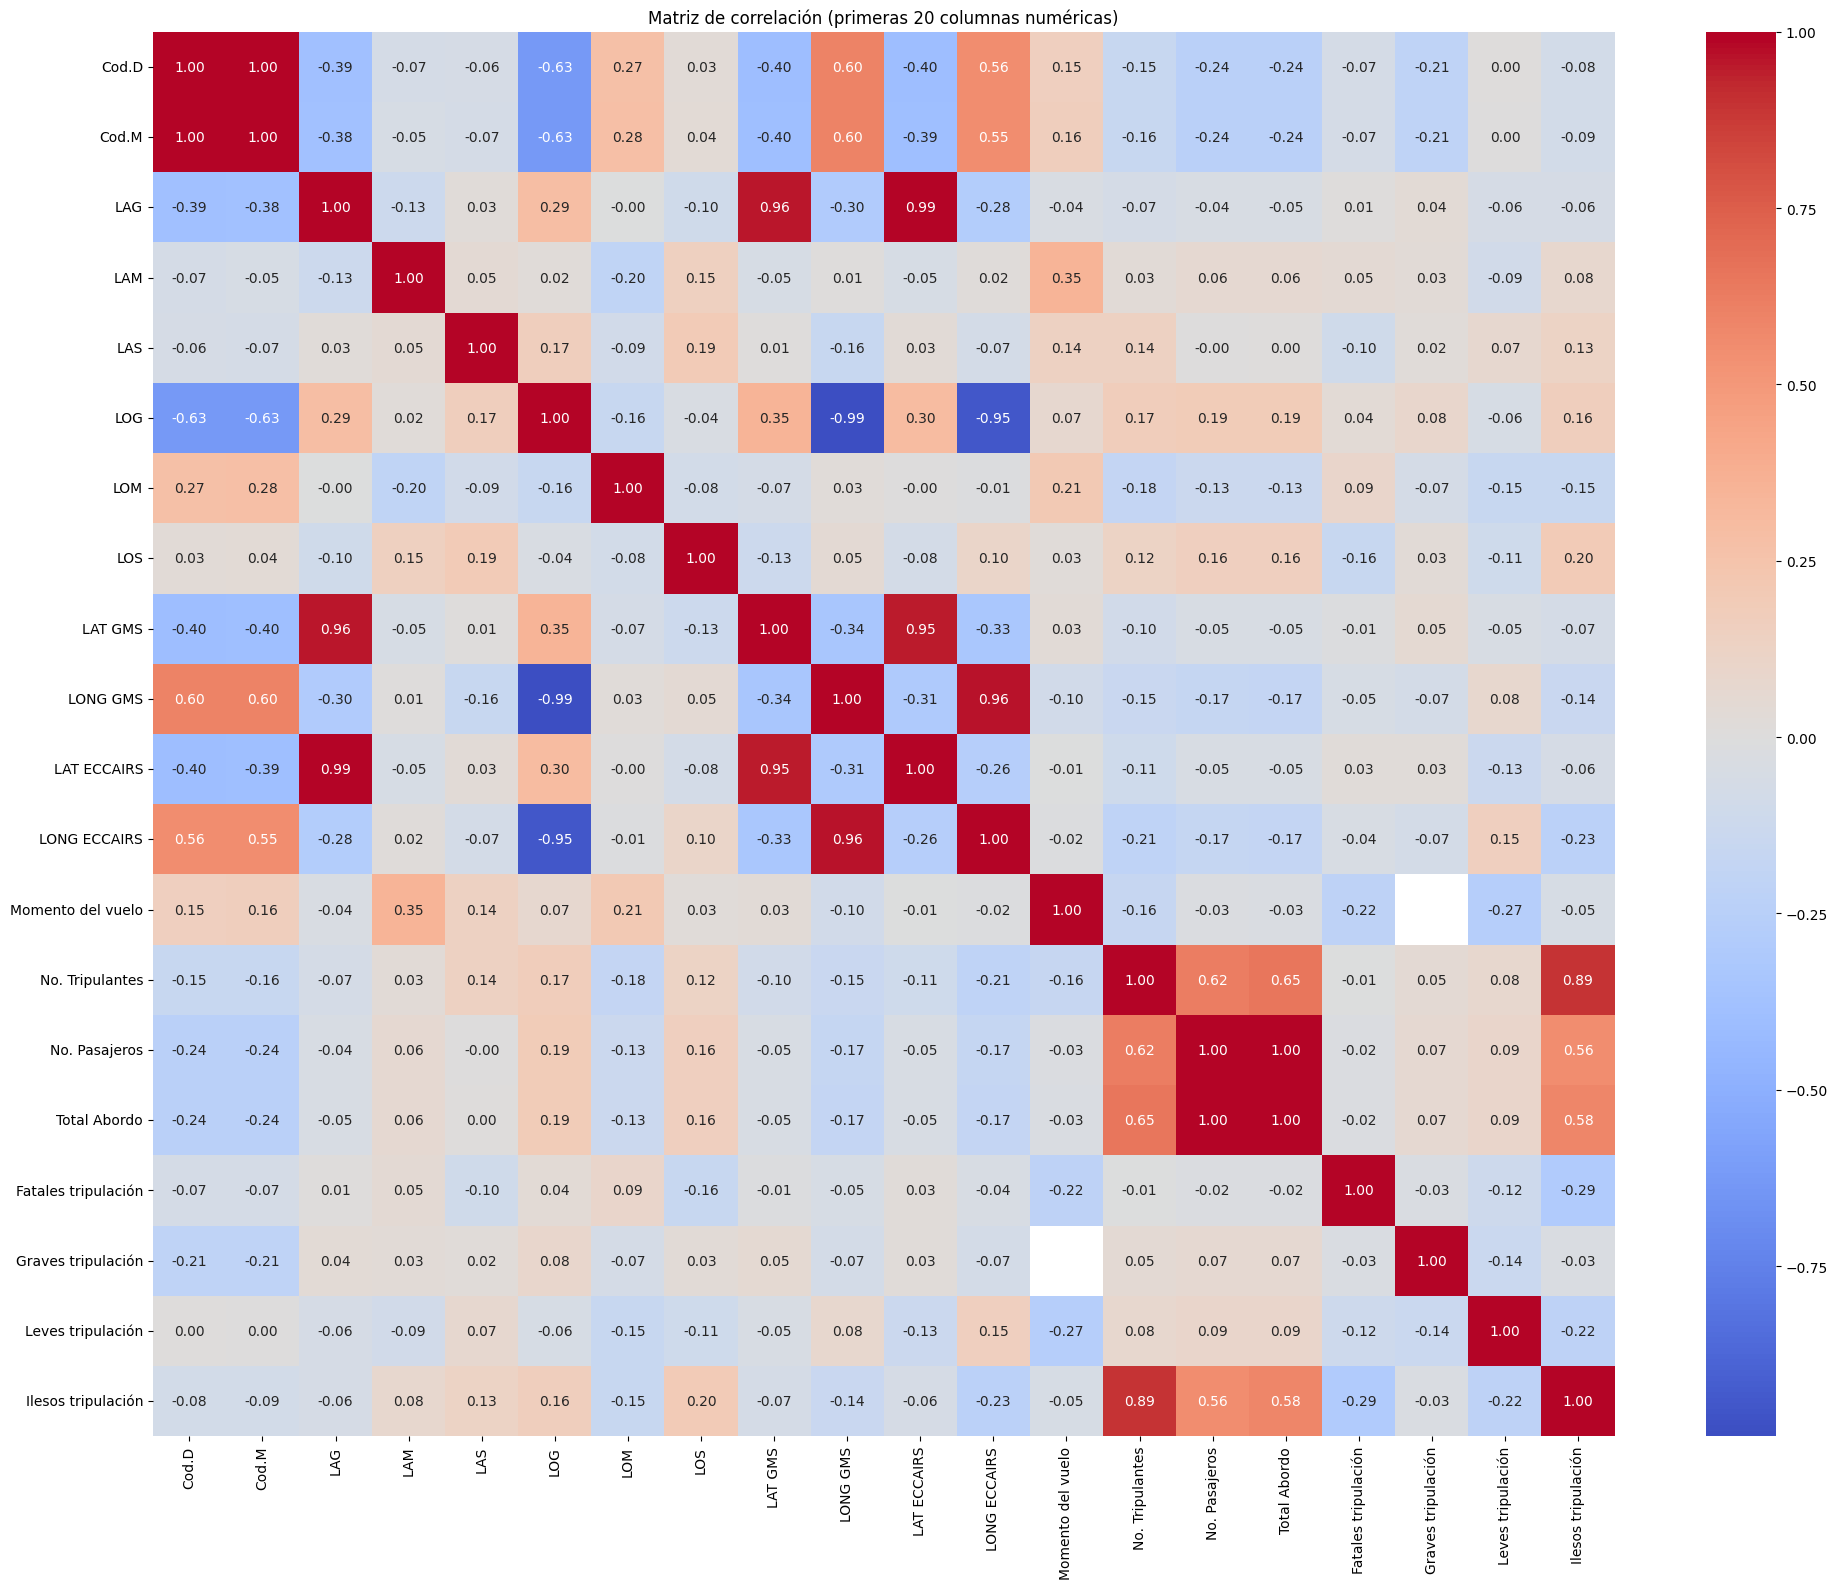

In [18]:
# ============================================================================
# 8. CORRELACIONES ENTRE VARIABLES NUMÉRICAS
# ============================================================================
if len(columnas_numericas) >= 2:
    print("\n8. MATRIZ DE CORRELACIONES")
    print("-"*50)

    # Calcular correlaciones
    correlaciones = df[columnas_numericas].corr()

    # Mostrar correlaciones más fuertes (|r| > 0.5)
    correlaciones_fuertes = []
    for i in range(len(correlaciones.columns)):
        for j in range(i+1, len(correlaciones.columns)):
            r = correlaciones.iloc[i, j]
            if abs(r) > 0.5 and not np.isnan(r):
                correlaciones_fuertes.append({
                    'Variable_1': correlaciones.columns[i],
                    'Variable_2': correlaciones.columns[j],
                    'Correlación': r
                })

    if correlaciones_fuertes:
        print("\nCorrelaciones fuertes encontradas (|r| > 0.5):")
        for corr in sorted(correlaciones_fuertes, key=lambda x: abs(x['Correlación']), reverse=True):
            print(f"  {corr['Variable_1']} ↔ {corr['Variable_2']}: {corr['Correlación']:.3f}")
    else:
        print("No se encontraron correlaciones fuertes entre variables numéricas")

    # Visualizar matriz de correlación (primeras 20 columnas)
    n_corr = min(len(columnas_numericas), 20)
    plt.figure(figsize=(20, 16))
    sns.heatmap(correlaciones.iloc[:n_corr, :n_corr], annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title(f'Matriz de correlación (primeras {n_corr} columnas numéricas)')
    plt.tight_layout()
    plt.savefig('matriz_correlacion.png', dpi=100)
    print("\n✓ Matriz de correlación guardada en: matriz_correlacion.png")

In [21]:
# ============================================================================
# 9. ANÁLISIS DE VARIABLES FECHA
# ============================================================================
if len(columnas_fecha) > 0:
    print("\n9. ANÁLISIS DE VARIABLES FECHA")
    print("-"*50)

    for col in columnas_fecha:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            print(f"\n  {col}:")
            print(f"    - Rango: {df[col].min()} a {df[col].max()}")
            print(f"    - Años disponibles: {df[col].dt.year.unique()[:10]}...")

            # Extraer componentes útiles para análisis numérico
            print(f"    - Componentes extraíbles: año, mes, día, día_semana, trimestre")

            # Propuesta de codificación numérica
            print(f"    - Propuesta: convertir a número de días desde época o usar año numérico")

In [22]:
# ============================================================================
# 10. RESUMEN EJECUTIVO Y RECOMENDACIONES
# ============================================================================
print("\n" + "="*80)
print("10. RESUMEN EJECUTIVO Y RECOMENDACIONES")
print("="*80)

print("""
HALLAZGOS PRINCIPALES:
----------------------------------------""")

print(f"1. Dimensión del dataset: {df.shape[0]} registros, {df.shape[1]} columnas")
print(f"2. Tipos de datos: {len(columnas_numericas)} numéricas, {len(columnas_categoricas)} categóricas, {len(columnas_fecha)} fechas")
print(f"3. Calidad de datos: {len(columnas_buenas)} columnas con <5% nulos, {len(columnas_malas)} columnas con >30% nulos")
print(f"4. Outliers detectados en {len(outliers_dict)} columnas numéricas")

print("""
RECOMENDACIONES PARA EL PROYECTO:
----------------------------------------""")

print("""
A. MANEJO DE DATOS NULOS:
   - Columnas con <5% nulos: eliminar filas con nulos o imputar con moda/media
   - Columnas con 5-30% nulos: imputación estratégica (media, mediana, moda según contexto)
   - Columnas con >30% nulos: evaluar si son realmente necesarias para el análisis

B. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (para análisis estadístico):
   - Variables binarias (2 categorías): codificar como 0/1
   - Variables nominales (3-10 categorías): usar One-Hot Encoding
   - Variables ordinales (con orden natural): asignar valores 1,2,3...
   - Variables con muchas categorías: agrupar las menos frecuentes en "Otros"

C. TRATAMIENTO DE OUTLIERS:
   - Investigar si los outliers son errores de datos o eventos reales (ej: accidente con 80 fatales)
   - Para estadísticas robustas: usar mediana en lugar de media
   - Para visualización: usar escalas logarítmicas o boxplots

D. VARIABLES ESPECÍFICAS PARA MÉTODOS NUMÉRICOS (según contenido del curso):
   - Interpolación: usar año y número de accidentes por año
   - Integración: área bajo curva de tendencia de accidentalidad
   - Diferencias finitas: tasa de cambio anual
   - Promedios y desviaciones: Total fatales, Porcentaje de supervivencia
   - Nube de palabras: usar Causa probable o Resumen del evento (conteo de frecuencias)
""")

# Guardar resumen completo
with open('eda_resumen_completo.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("EDA - BASE DE DATOS ACCIDENTES AÉREOS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Dimensiones: {df.shape}\n\n")
    f.write("Columnas numéricas:\n")
    f.write(str(columnas_numericas) + "\n\n")
    f.write("Columnas categóricas:\n")
    f.write(str(columnas_categoricas) + "\n\n")
    f.write("Resumen nulos:\n")
    f.write(nulos_df.to_string() + "\n\n")
    f.write("Propuesta codificación:\n")
    f.write(df_codificacion.to_string())

print("\n✓ Resumen completo guardado en: eda_resumen_completo.txt")
print("\n" + "="*80)
print("EDA COMPLETADO EXITOSAMENTE")
print("="*80)


10. RESUMEN EJECUTIVO Y RECOMENDACIONES

HALLAZGOS PRINCIPALES:
----------------------------------------
1. Dimensión del dataset: 112 registros, 177 columnas
2. Tipos de datos: 61 numéricas, 116 categóricas, 0 fechas
3. Calidad de datos: 88 columnas con <5% nulos, 63 columnas con >30% nulos
4. Outliers detectados en 4 columnas numéricas

RECOMENDACIONES PARA EL PROYECTO:
----------------------------------------

A. MANEJO DE DATOS NULOS:
   - Columnas con <5% nulos: eliminar filas con nulos o imputar con moda/media
   - Columnas con 5-30% nulos: imputación estratégica (media, mediana, moda según contexto)
   - Columnas con >30% nulos: evaluar si son realmente necesarias para el análisis

B. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (para análisis estadístico):
   - Variables binarias (2 categorías): codificar como 0/1
   - Variables nominales (3-10 categorías): usar One-Hot Encoding
   - Variables ordinales (con orden natural): asignar valores 1,2,3...
   - Variables con muchas categoría